# Reviewed Dipper Wavelet Atlas

This notebook makes one light-curve/phase-fold/wavelet/global-power figure for **every candidate currently labeled `dipper` in the Review database**. Rerun it after identifying new dippers; the sample is queried live rather than maintained as a hand-written list.

ASAS-SN sampling is irregular and contains seasonal gaps, so the analysis uses a weighted wavelet Z-transform (WWZ) directly on observed nightly fluxes. It does not interpolate across gaps. Gray regions in the time-scale map lack enough local support or fall inside the edge cone. The red lines mark the dominant time-averaged WWZ scale and its contiguous half-maximum band.

## Parameters and imports

The default run is the July 1 Review database. `MAX_CANDIDATES = None` processes all current dippers. For a quick test, set it to a small integer or launch with `MALCA_WAVELET_MAX_CANDIDATES=1`.

The upper scale is adaptive: by default it is 50% of each light curve's observed span, corresponding to a minimum of two cycles across the full baseline. `max_scale_days=None` means there is no additional fixed-day cap. Set it to a number only when you intentionally want a common hard ceiling. The gray cone marks long-scale/time combinations affected by the finite data edges; those cells remain visible as diagnostics rather than being deleted.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from malca.io.lightcurve_io import load_lightcurve_df
from malca.io.notebook_paths import find_repo_root, resolve_local_lightcurve_path
from malca.plotting.dipper_wavelet import (
    WWZConfig,
    analyze_wavelet,
    generate_wavelet_atlas,
    plot_wavelet_figure,
    prepare_relative_flux,
    read_review_labeled_candidates,
)

REPO_ROOT = find_repo_root()
RUN_NAME = "dat3-full-extended_2026-07-01-v4"
RUN_ROOT = REPO_ROOT / "output" / "runs" / RUN_NAME
REVIEW_DB = RUN_ROOT / "review" / "review.db"
OUTPUT_DIR_TEXT = os.environ.get("MALCA_WAVELET_OUTPUT_DIR", "").strip()
OUTPUT_DIR = Path(OUTPUT_DIR_TEXT).expanduser() if OUTPUT_DIR_TEXT else REPO_ROOT / "output" / "notebooks" / "july1_dipper_wavelet_atlas"
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = REPO_ROOT / OUTPUT_DIR
EVENT_CLASS = "dipper"

MAX_CANDIDATES_TEXT = os.environ.get("MALCA_WAVELET_MAX_CANDIDATES", "").strip()
MAX_CANDIDATES = int(MAX_CANDIDATES_TEXT) if MAX_CANDIDATES_TEXT else None
RUN_BATCH = os.environ.get("MALCA_WAVELET_RUN_BATCH", "1").strip().lower() not in {"0", "false", "no", "off"}
WRITE_PNG = True
WRITE_INDIVIDUAL_PDF = True
BUILD_ATLAS_PDF = True

WWZ_CONFIG = WWZConfig(
    min_scale_days=2.0,
    max_scale_days=None,
    max_scale_fraction_of_span=0.50,
    n_scales=72,
    n_time_bins=180,
    decay_constant=0.0125,
    min_effective_points=10.0,
    min_nights=30,
)

assert RUN_ROOT.is_dir(), RUN_ROOT
assert REVIEW_DB.is_file(), REVIEW_DB
print(f"review DB : {REVIEW_DB}")
print(f"output dir: {OUTPUT_DIR}")
print(f"limit     : {MAX_CANDIDATES if MAX_CANDIDATES is not None else 'all current dippers'}")

review DB : /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
output dir: /Users/calder/code/malca/output/notebooks/july1_dipper_wavelet_atlas
limit     : all current dippers


## Query the current dipper sample

Selection uses only `reviews.event_class = 'dipper'`. It does not impose a YSO, confidence, morphology, or final-class cut.

In [2]:
candidates = read_review_labeled_candidates(REVIEW_DB, event_class=EVENT_CLASS)
display(Markdown(f"**Current reviewed dipper sample:** {len(candidates):,} unique candidates"))
display(candidates.head(10))
assert candidates['candidate_id'].is_unique

**Current reviewed dipper sample:** 164 unique candidates

,candidate_id,asas_sn_id,lc_path,ra,dec,periodicity_period,periodicity_method,event_class,classification_confidence,workflow_status,status
0,stv_111669291649,111669291649,/Users/calder/code/malca/output/runs/dat3-full...,42.084955,61.828395,1537.035083,long_ls+events,dipper,4,reviewed,reviewed
1,stv_111669305159,111669305159,/Users/calder/code/malca/output/runs/dat3-full...,23.378659,61.901244,2459.863938,long_ls,dipper,4,reviewed,reviewed
2,stv_111670309173,111670309173,/Users/calder/code/malca/output/runs/dat3-full...,308.822847,33.428341,2428.796508,long_ls,dipper,4,reviewed,reviewed
3,stv_111670547411,111670547411,/Users/calder/code/malca/output/runs/dat3-full...,339.635000,58.642067,2508.168876,long_ls,dipper,4,reviewed,reviewed
4,stv_120259148405,120259148405,/Users/calder/code/malca/output/runs/dat3-full...,70.836066,47.910700,2471.258196,long_ls,dipper,4,reviewed,reviewed
5,stv_120259356690,120259356690,/Users/calder/code/malca/output/runs/dat3-full...,2.716114,62.169295,2447.292090,long_ls+events,dipper,4,reviewed,reviewed
6,stv_120259975222,120259975222,/Users/calder/code/malca/output/runs/dat3-full...,303.537401,40.497287,681.951780,long_ls+events,dipper,4,reviewed,reviewed
7,stv_128850429575,128850429575,/Users/calder/code/malca/output/runs/dat3-full...,299.124253,36.774001,2305.620140,long_ls+events,dipper,4,reviewed,reviewed
8,stv_137440061640,137440061640,/Users/calder/code/malca/output/runs/dat3-full...,65.614628,29.789126,2660.341404,long_ls+events,dipper,4,reviewed,reviewed
9,stv_146029052740,146029052740,/Users/calder/code/malca/output/runs/dat3-full...,342.773585,57.555867,2435.910348,long_ls,dipper,4,reviewed,reviewed


## What is being measured?

Each quality-filtered light curve is converted from magnitude to relative flux after normalizing the `V` and `g` passbands separately. Multiple exposures in one UTC observing night are combined with a median. WWZ then fits a locally time-weighted constant + sine + cosine model at every displayed time and scale.

The right panel is the mean valid WWZ power over time. Its peak is a **dominant variability scale**, not by itself proof of a coherent period. Significance and periodicity should still be checked with MALCA's bootstrap LSP/CE products and with the light curve. If the peak or half-maximum band reaches the adaptive upper boundary, the annotation and output manifest flag it as boundary-limited rather than presenting the edge value as a completed measurement.

## Preview one candidate

This is an interactive check of the full computation before the batch export.

stv_111669291649: 1,734 exposures, 1,326 nights, dominant scale=1685.84 d, maximum analyzed scale=2049.37 d, upper-bound limited=False, edge-reliable fraction=0.00


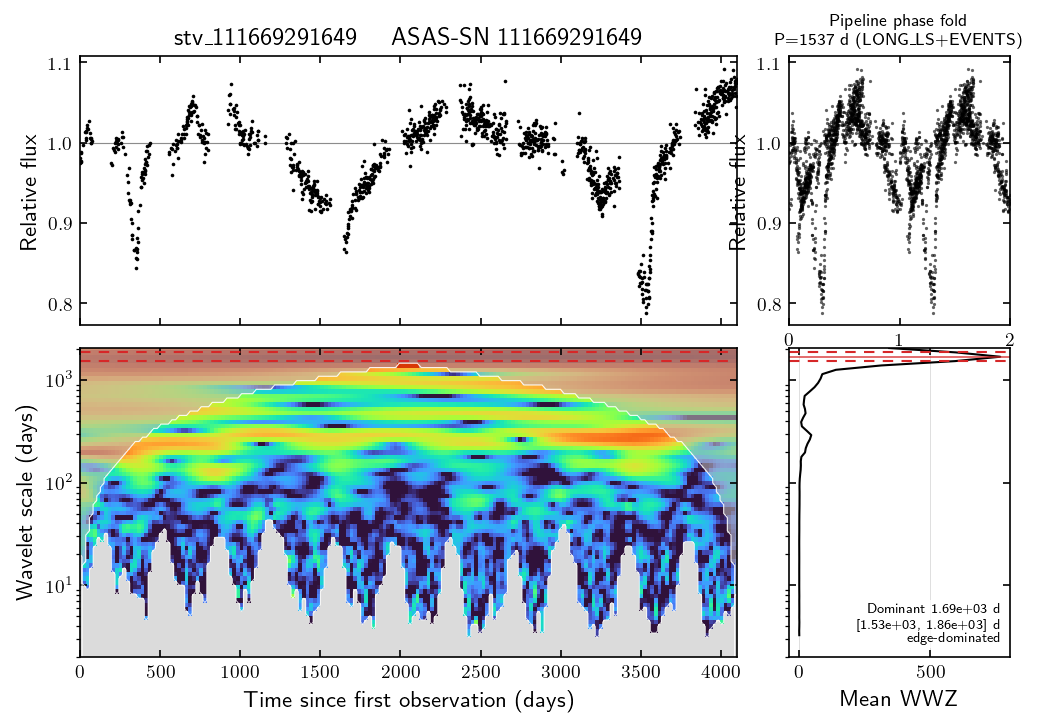

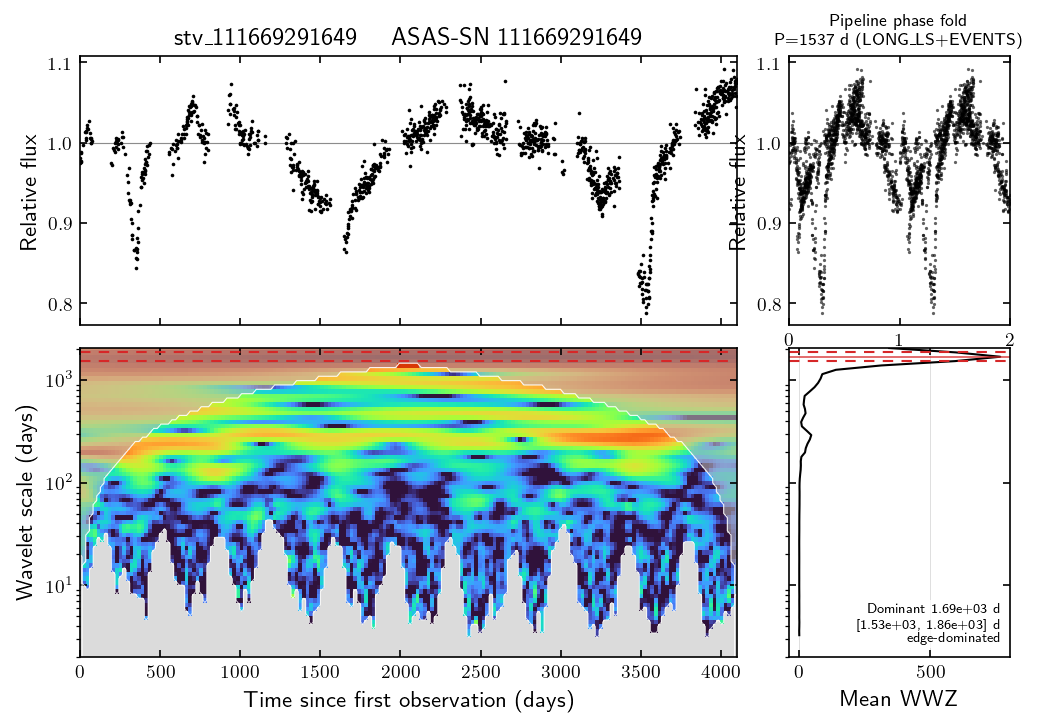

In [3]:
preview_row = candidates.iloc[0]
preview_path = resolve_local_lightcurve_path(preview_row['lc_path'], run_dir=RUN_ROOT)
assert preview_path is not None and preview_path.is_file(), preview_path

preview_lc = load_lightcurve_df(
    preview_path,
    filter_bad_cameras_enabled=True,
    apply_quality=True,
)
preview_nightly = prepare_relative_flux(preview_lc)
preview_result = analyze_wavelet(preview_nightly, config=WWZ_CONFIG)
print(
    f"{preview_row['candidate_id']}: {len(preview_lc):,} exposures, "
    f"{len(preview_nightly):,} nights, "
    f"dominant scale={preview_result.dominant_scale_days:.2f} d, "
    f"maximum analyzed scale={preview_result.max_scale_analyzed_days:.2f} d, "
    f"upper-bound limited={preview_result.dominant_peak_at_upper_boundary}, "
    f"edge-reliable fraction={preview_result.dominant_scale_edge_reliable_fraction:.2f}"
)
preview_figure = plot_wavelet_figure(
    preview_result,
    candidate_id=str(preview_row['candidate_id']),
    asas_sn_id=str(preview_row['asas_sn_id']),
    period_days=preview_row['periodicity_period'],
    period_source=preview_row['periodicity_method'],
)
preview_figure

## Export every current dipper

Outputs include one PNG and PDF per candidate, a single multipage PDF atlas, and a CSV manifest with point counts, cadence, dominant scale, valid-map fraction, and any per-candidate error.

In [4]:
if RUN_BATCH:
    manifest = generate_wavelet_atlas(
        candidates,
        run_root=RUN_ROOT,
        output_dir=OUTPUT_DIR,
        config=WWZ_CONFIG,
        max_candidates=MAX_CANDIDATES,
        write_png=WRITE_PNG,
        write_pdf=WRITE_INDIVIDUAL_PDF,
        build_atlas_pdf=BUILD_ATLAS_PDF,
        progress=True,
    )
else:
    manifest = pd.DataFrame()
    print('Batch export disabled by MALCA_WAVELET_RUN_BATCH=0')

[1/164] stv_111669291649
[2/164] stv_111669305159
[3/164] stv_111670309173
[4/164] stv_111670547411
[5/164] stv_120259148405
[6/164] stv_120259356690
[7/164] stv_120259975222
[8/164] stv_128850429575
[9/164] stv_137440061640
[10/164] stv_146029052740
[11/164] stv_146029595645
[12/164] stv_163209590869
[13/164] stv_17181027305
[14/164] stv_180388640882
[15/164] stv_180388903123
[16/164] stv_197569226514
[17/164] stv_206158504352
[18/164] stv_214748665650
[19/164] stv_240518717560
[20/164] stv_240519504803
[21/164] stv_266288257407
[22/164] stv_283467842509
[23/164] stv_283468165807
[24/164] stv_292057989013
[25/164] stv_300648040390
[26/164] stv_300648890329
[27/164] stv_34360122433
[28/164] stv_34360173609
[29/164] stv_352188453021
[30/164] stv_360777789109
[31/164] stv_360777826205
[32/164] stv_369367304600
[33/164] stv_369367581586
[34/164] stv_369368258528
[35/164] stv_395137536331
[36/164] stv_420907788679
[37/164] stv_429497765184
[38/164] stv_42950519514
[39/164] stv_463856558214

## Batch quality control

A clean run has one `ok` manifest row per selected candidate. Inspect any errors rather than silently dropping them.

In [5]:
if not manifest.empty:
    expected_rows = len(candidates) if MAX_CANDIDATES is None else min(MAX_CANDIDATES, len(candidates))
    status_counts = manifest['plot_status'].value_counts(dropna=False).rename_axis('plot_status').to_frame('count')
    display(status_counts)
    display(manifest.head(20))
    print(f"atlas   : {OUTPUT_DIR / 'all_dipper_wavelet_atlas.pdf'}")
    print(f"manifest: {OUTPUT_DIR / 'wavelet_manifest.csv'}")
    assert len(manifest) == expected_rows, (len(manifest), expected_rows)
    failures = manifest.loc[manifest['plot_status'].ne('ok')]
    if not failures.empty:
        display(failures[['candidate_id', 'lc_path', 'error']])
        raise RuntimeError(f"{len(failures)} wavelet figures failed; see the table above")
    print(f"Validated {len(manifest):,}/{expected_rows:,} requested wavelet figures")

,count
plot_status,
ok,164


,candidate_id,asas_sn_id,phase_period_days,phase_source,plot_status,error,lc_path,n_quality_exposures,n_nights,span_days,...,dominant_scale_low_days,dominant_scale_high_days,dominant_peak_at_upper_boundary,dominant_band_hits_upper_boundary,dominant_scale_edge_reliable_fraction,max_scale_analyzed_days,valid_wwz_fraction,edge_reliable_wwz_fraction,png_path,pdf_path
0,stv_111669291649,111669291649,1537.035083,long_ls+events,ok,,/Users/calder/code/malca/output/runs/dat3-full...,1734,1326,4098.748370,...,1529.020048,1858.739668,False,False,0.000000,2049.374185,0.763889,0.795833,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
1,stv_111669305159,111669305159,2459.863938,long_ls,ok,,/Users/calder/code/malca/output/runs/dat3-full...,924,891,4099.773230,...,1859.197884,2049.886615,True,True,0.000000,2049.886615,0.712577,0.795833,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
2,stv_111670309173,111670309173,2428.796508,long_ls,ok,,/Users/calder/code/malca/output/runs/dat3-full...,910,895,4047.994180,...,1665.547140,2023.997090,True,True,0.000000,2023.997090,0.721914,0.795525,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
3,stv_111670547411,111670547411,2508.168876,long_ls,ok,,/Users/calder/code/malca/output/runs/dat3-full...,857,840,4180.281460,...,1895.188235,2090.140730,True,True,0.000000,2090.140730,0.708333,0.796142,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
4,stv_120259148405,120259148405,2471.258196,long_ls,ok,,/Users/calder/code/malca/output/runs/dat3-full...,835,813,4118.763660,...,1145.887360,2059.381830,True,True,0.000000,2059.381830,0.699537,0.795833,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
5,stv_120259356690,120259356690,2447.292090,long_ls+events,ok,,/Users/calder/code/malca/output/runs/dat3-full...,1790,1347,4151.343220,...,1547.806227,2075.671610,False,True,0.000000,2075.671610,0.773920,0.795833,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
6,stv_120259975222,120259975222,681.951780,long_ls+events,ok,,/Users/calder/code/malca/output/runs/dat3-full...,891,883,4026.975170,...,923.829636,1237.302214,False,False,0.200000,2013.487585,0.717052,0.795062,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
7,stv_128850429575,128850429575,2305.620140,long_ls+events,ok,,/Users/calder/code/malca/output/runs/dat3-full...,1004,990,4026.962610,...,1826.640100,2013.481305,True,True,0.000000,2013.481305,0.730556,0.795062,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
8,stv_137440061640,137440061640,2660.341404,long_ls+events,ok,,/Users/calder/code/malca/output/runs/dat3-full...,1327,1163,4435.665660,...,2217.832830,2217.832830,True,True,0.000000,2217.832830,0.739506,0.798457,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...
9,stv_146029052740,146029052740,2435.910348,long_ls,ok,,/Users/calder/code/malca/output/runs/dat3-full...,840,823,4059.850580,...,1515.119729,2029.925290,True,True,0.000000,2029.925290,0.707870,0.795525,/Users/calder/code/malca/output/notebooks/july...,/Users/calder/code/malca/output/notebooks/july...


atlas   : /Users/calder/code/malca/output/notebooks/july1_dipper_wavelet_atlas/all_dipper_wavelet_atlas.pdf
manifest: /Users/calder/code/malca/output/notebooks/july1_dipper_wavelet_atlas/wavelet_manifest.csv
Validated 164/164 requested wavelet figures
